In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate, cross_val_score, cross_val_predict
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    accuracy_score,
    recall_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.base import clone

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

In [3]:
PATHX_TE = r"C:\Users\erika\Downloads\DD\DD/X_TE.csv" 
PATHX_TR = r"C:\Users\erika\Downloads\DD\DD/X_TR.csv"
PATHy_TR = r"C:\Users\erika\Downloads\DD\DD/y_TR.csv"

X_TE = pd.read_csv(PATHX_TE)
X_TR = pd.read_csv(PATHX_TR)
y_TR = pd.read_csv(PATHy_TR).squeeze("columns")
classes=np.unique(y_TR)

print(X_TE.shape)
print(X_TR.shape)
print(y_TR.shape)

(2320, 820)
(8080, 820)
(8080,)


#######
PART 1A
#######

class
7    1630
2    1308
3    1214
6    1204
5    1164
1    1071
4     489
Name: count, dtype: int64


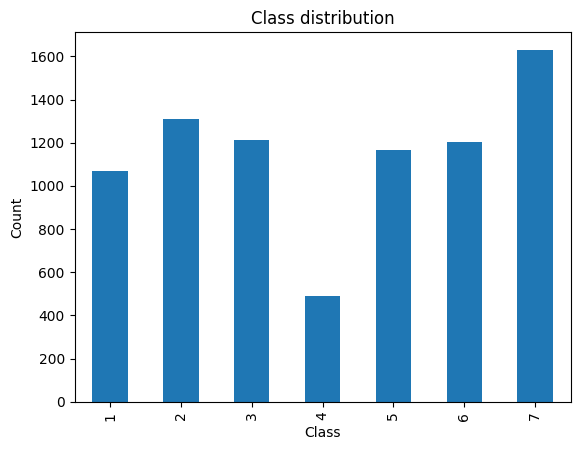

In [4]:
print(y_TR.value_counts())
y_TR.value_counts().sort_index().plot.bar()

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()

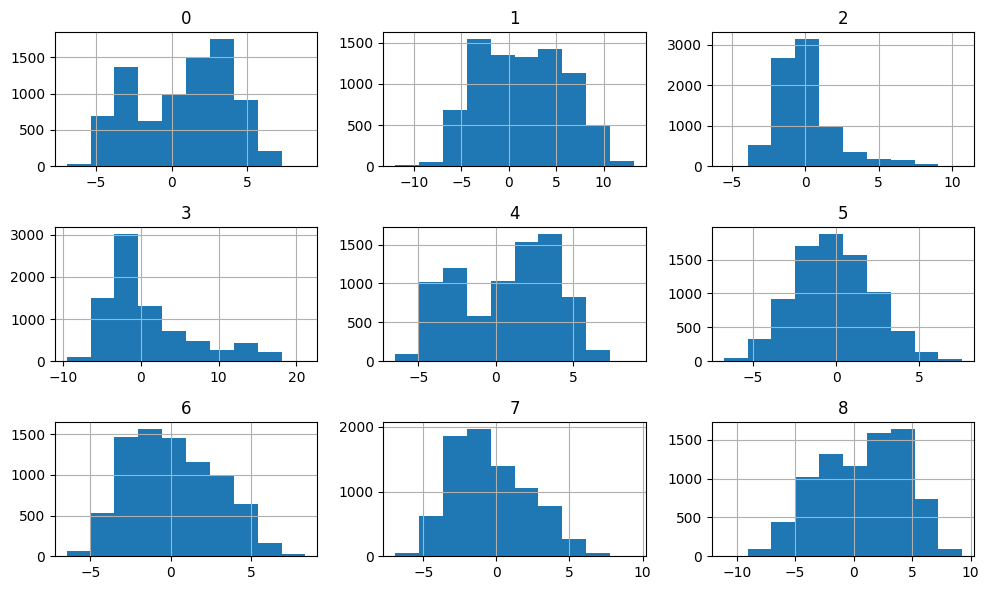

,count,mean,std,min,25%,50%,75%,max
0,8080.0,0.753198,3.103232,-6.929226,-2.314936,1.349150,3.285065,8.835516
1,8080.0,1.418927,4.442396,-11.977769,-2.361169,1.299327,5.037949,13.172900
2,8080.0,0.025040,2.005000,-5.540027,-1.205507,-0.331619,0.720956,10.690080
3,8080.0,0.879485,5.609846,-9.490943,-2.956033,-1.036813,3.238822,21.141222
4,8080.0,0.730555,3.119917,-6.497867,-2.372135,1.344077,3.299508,8.938582


In [5]:
X_TR.iloc[:, :9].hist(figsize=(10,6))
plt.tight_layout()
plt.show()
X_TR.describe().T.head()

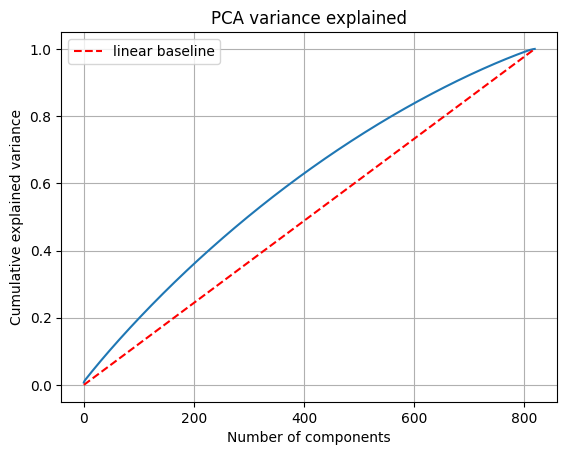

In [6]:
X_scaled = StandardScaler().fit_transform(X_TR)

pca = PCA()
pca.fit(X_scaled)

explained = np.cumsum(pca.explained_variance_ratio_)

plt.plot(explained)

n = len(explained)
plt.plot([0, n-1], [0, 1], linestyle='--', color='red', label='linear baseline')

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA variance explained")
plt.grid()
plt.legend()
plt.show()

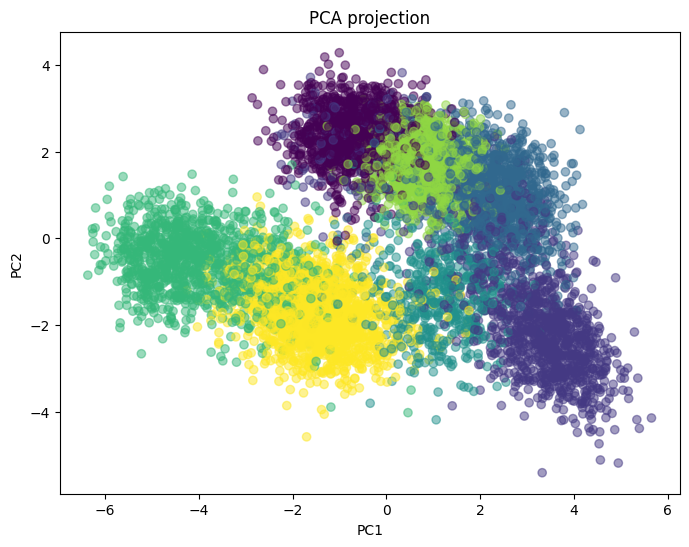

In [34]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_TR,
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection")
plt.show()

In [20]:
models = {
    "logreg_l2": (
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("vt", VarianceThreshold()),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                l1_ratio=0,
                solver="saga",
                class_weight="balanced",
                max_iter=2000,
                random_state=42
            ))
        ]),
        {
            "clf__C": [0.1, 1.0]
        }
    ),

    "linear_svm": (
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("vt", VarianceThreshold()),
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(
                class_weight="balanced",
                max_iter=5000,
                random_state=42,
                dual=False
            ))
        ]),
        {
            "clf__C": [0.1, 1.0]
        }
    ),

    "random_forest": (
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("vt", VarianceThreshold()),
            ("clf", RandomForestClassifier(
                class_weight="balanced_subsample",
                n_estimators=150,
                random_state=42,
                n_jobs=-1
            ))
        ]),
        {
            "clf__max_depth": [None, 20],
            "clf__min_samples_leaf": [1, 3]
        }
    )
}

In [ ]:
sample_sizes = [1000, 3000, 8080]

outer_seeds = [3, 6, 9]

outer_folds = 5
inner_folds = 2

rows = []

for sample_size in sample_sizes:

    print("\n" + "=" * 60)
    print(f"SAMPLE SIZE = {sample_size}")
    print("=" * 60)

    for seed in outer_seeds:

        rng = np.random.RandomState(seed)

        sampled_idx = []

        for cls in classes:

            cls_idx = np.where(y_TR.values == cls)[0]

            n_cls = int(
                np.round(
                    sample_size *
                    len(cls_idx) /
                    len(y_TR)
                )
            )

            n_cls = max(1, n_cls)

            sampled_idx.extend(
                rng.choice(
                    cls_idx,
                    size=n_cls,
                    replace=False
                )
            )

        sampled_idx = np.array(sampled_idx)

        X_sub = X_TR.iloc[sampled_idx].reset_index(drop=True)
        y_sub = y_TR.iloc[sampled_idx].reset_index(drop=True)

        print(f"\nSeed {seed} | n = {len(y_sub)}")

        for model_name, (pipe, param_grid) in models.items():

            print(f"\nStarting {model_name}")

            outer_cv = StratifiedKFold(
                n_splits=outer_folds,
                shuffle=True,
                random_state=seed
            )

            for fold, (train_idx, test_idx) in enumerate(
                outer_cv.split(X_sub, y_sub),
                start=1
            ):

                print(
                    f"Model={model_name} "
                    f"Seed={seed} "
                    f"Fold={fold}/{outer_folds}"
                )

                X_train = X_sub.iloc[train_idx]
                X_test = X_sub.iloc[test_idx]

                y_train = y_sub.iloc[train_idx]
                y_test = y_sub.iloc[test_idx]

                inner_cv = StratifiedKFold(
                    n_splits=inner_folds,
                    shuffle=True,
                    random_state=seed + 100
                )

                search = GridSearchCV(
                    estimator=pipe,
                    param_grid=param_grid,
                    scoring="balanced_accuracy",
                    cv=inner_cv,
                    n_jobs=-1,
                    refit=True
                )

                search.fit(X_train, y_train)

                y_pred = search.predict(X_test)

                row = {
                    "sample_size": sample_size,
                    "model": model_name,
                    "seed": seed,
                    "fold": fold,
                    "balanced_accuracy":
                        balanced_accuracy_score(y_test, y_pred),
                    "macro_f1":
                        f1_score(y_test, y_pred, average="macro"),
                    "accuracy":
                        accuracy_score(y_test, y_pred),
                    "best_params":
                        str(search.best_params_)
                }

                per_class_recall = recall_score(
                    y_test,
                    y_pred,
                    labels=classes,
                    average=None,
                    zero_division=0
                )

                for c, r in zip(classes, per_class_recall):
                    row[f"recall_class_{c}"] = r

                rows.append(row)

                print(
                    f"Done | BA={row['balanced_accuracy']:.3f} "
                    f"| F1={row['macro_f1']:.3f}"
                )

results_df = pd.DataFrame(rows)


SAMPLE SIZE = 1000

Seed 3 | n = 1001

Starting logreg_l2
Model=logreg_l2 Seed=3 Fold=1/5
Done | BA=0.646 | F1=0.657
Model=logreg_l2 Seed=3 Fold=2/5
Done | BA=0.598 | F1=0.604
Model=logreg_l2 Seed=3 Fold=3/5
Done | BA=0.685 | F1=0.701
Model=logreg_l2 Seed=3 Fold=4/5
Done | BA=0.677 | F1=0.692
Model=logreg_l2 Seed=3 Fold=5/5
Done | BA=0.647 | F1=0.650

Starting linear_svm
Model=linear_svm Seed=3 Fold=1/5
Done | BA=0.562 | F1=0.569
Model=linear_svm Seed=3 Fold=2/5
Done | BA=0.509 | F1=0.517
Model=linear_svm Seed=3 Fold=3/5
Done | BA=0.608 | F1=0.615
Model=linear_svm Seed=3 Fold=4/5
Done | BA=0.553 | F1=0.564
Model=linear_svm Seed=3 Fold=5/5
Done | BA=0.604 | F1=0.610

Starting random_forest
Model=random_forest Seed=3 Fold=1/5
Done | BA=0.926 | F1=0.931
Model=random_forest Seed=3 Fold=2/5
Done | BA=0.865 | F1=0.876
Model=random_forest Seed=3 Fold=3/5
Done | BA=0.891 | F1=0.897
Model=random_forest Seed=3 Fold=4/5
Done | BA=0.940 | F1=0.944
Model=random_forest Seed=3 Fold=5/5
Done | BA=0.8

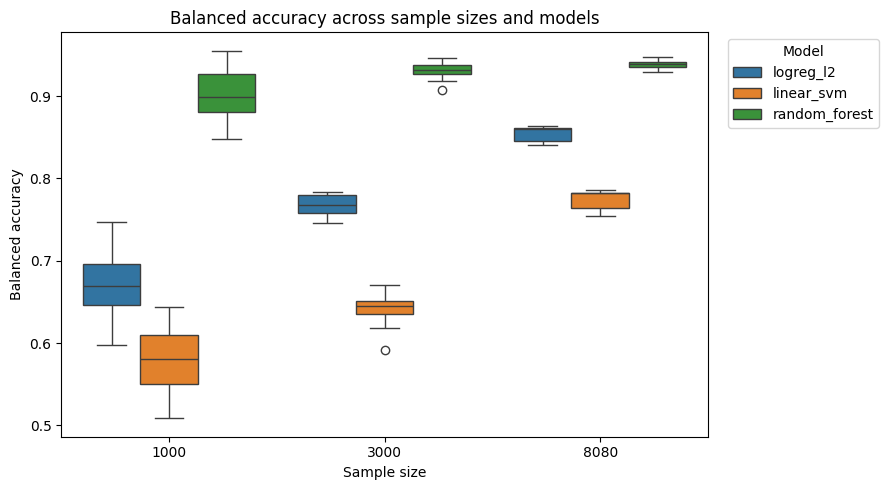

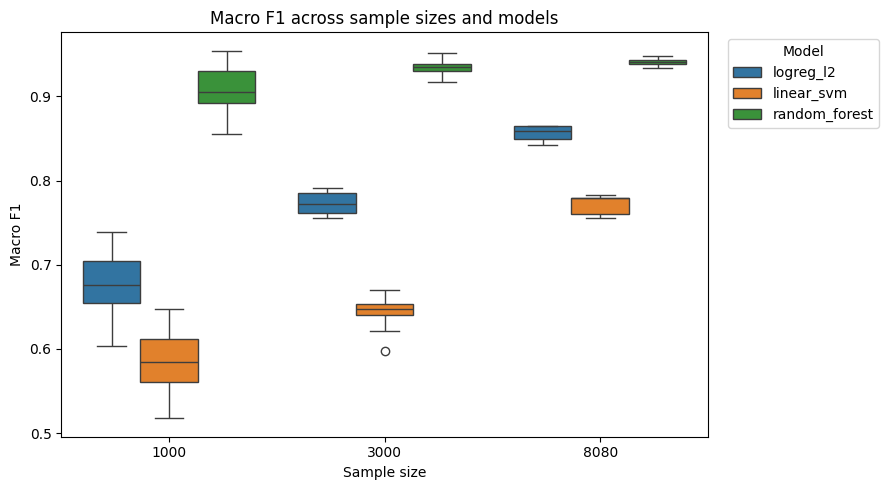

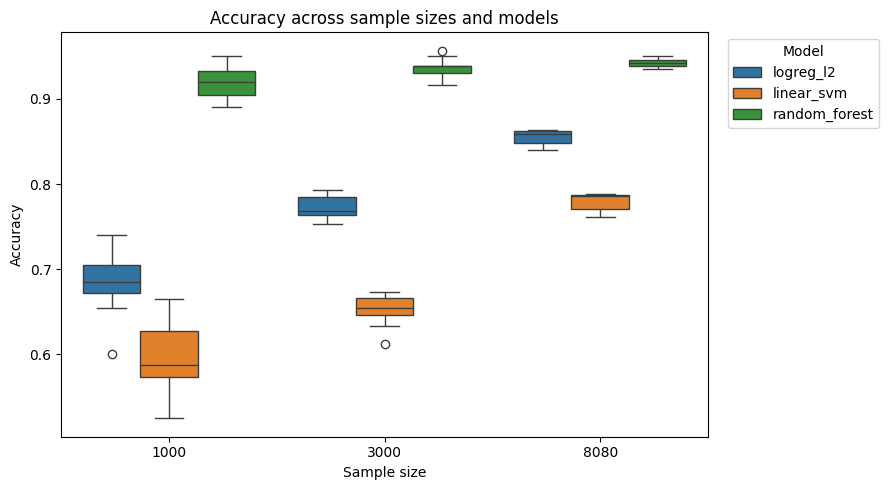

In [25]:
plot_df = results_df.copy()
plot_df["sample_size"] = plot_df["sample_size"].astype(str)

metric_names = {
    "balanced_accuracy": "Balanced accuracy",
    "macro_f1": "Macro F1",
    "accuracy": "Accuracy"
}

for metric, label in metric_names.items():
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=plot_df, x="sample_size", y=metric, hue="model")
    plt.xlabel("Sample size")
    plt.ylabel(label)
    plt.title(f"{label} across sample sizes and models")
    plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

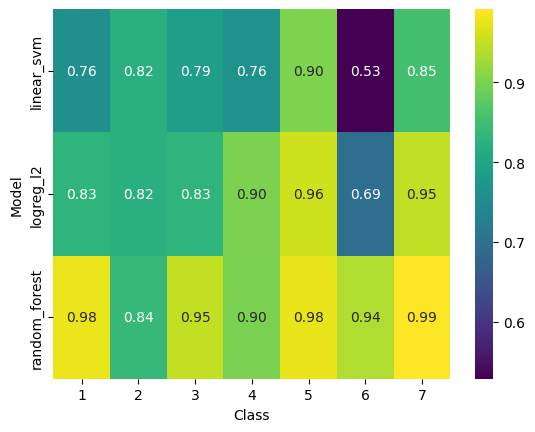

In [ ]:
heatmap_df = (
    results_df[results_df["sample_size"] == 8080]
    .groupby("model")[recall_cols]
    .mean()
)

heatmap_df.columns = [
    col.replace("recall_class_", "")
    for col in heatmap_df.columns
]

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.xlabel("Class")
plt.ylabel("Model")
plt.show()

In [9]:
rf = RandomForestClassifier(
    n_estimators=150,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_TR, y_TR)

imp = np.sort(rf.feature_importances_)[::-1]

cum_imp = np.cumsum(imp)

n80 = np.argmax(cum_imp >= 0.80) + 1

print("Features explaining 80% importance:", n80)

Features explaining 80% importance: 437


In [12]:
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("vt", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        l1_ratio=1,
        solver="saga",
        C=0.1,
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

pipe.fit(X_TR, y_TR)

coef = pipe.named_steps["clf"].coef_

n_features_selected = np.sum(np.any(np.abs(coef) > 1e-8, axis=0))

print("Selected features:", n_features_selected)

Selected features: 633


#######
PART 1b
#######

In [ ]:
rf_ranker = RandomForestClassifier(
    n_estimators=150,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_ranker.fit(X_TR, y_TR)

importance_df = pd.DataFrame({
    "feature": X_TR.columns,
    "importance": rf_ranker.feature_importances_
}).sort_values("importance", ascending=False)

top3_features = importance_df.head(3)["feature"].tolist()
print("Top 3 features to remove:", top3_features)

# create disrupted data

X_TR_disrupted = X_TR.drop(columns=top3_features).reset_index(drop=True)
y = pd.Series(y_TR).reset_index(drop=True)

# evaluate clean vs disrupted in same pipeline

datasets = {
    "clean": X_TR.reset_index(drop=True),
    "disrupted": X_TR_disrupted
}

outer_seeds = [3, 6, 9]
outer_folds = 5
inner_folds = 2

rows = []

for data_name, X_data in datasets.items():
    print(f"\n===== Dataset: {data_name} =====")

    for model_name, (pipe, param_grid) in models.items():
        print(f"\n--- Model: {model_name} ---")

        for seed in outer_seeds:
            cv = StratifiedKFold(n_splits=outer_folds, shuffle=True, random_state=seed)

            for fold, (train_idx, test_idx) in enumerate(cv.split(X_data, y), start=1):
                X_train, X_test = X_data.iloc[train_idx], X_data.iloc[test_idx]
                y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

                search = GridSearchCV(
                    estimator=pipe,
                    param_grid=param_grid,
                    scoring="balanced_accuracy",
                    cv=inner_folds,
                    n_jobs=-1,
                    refit=True
                )
                search.fit(X_train, y_train)

                y_pred = search.predict(X_test)

                row = {
                    "dataset": data_name,
                    "model": model_name,
                    "seed": seed,
                    "fold": fold,
                    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
                    "macro_f1": f1_score(y_test, y_pred, average="macro"),
                    "accuracy": accuracy_score(y_test, y_pred),
                    "best_params": str(search.best_params_)
                }

                per_class_recall = recall_score(
                    y_test,
                    y_pred,
                    labels=np.sort(y.unique()),
                    average=None,
                    zero_division=0
                )
                for c, r in zip(np.sort(y.unique()), per_class_recall):
                    row[f"recall_class_{c}"] = r

                rows.append(row)

results_1b = pd.DataFrame(rows)

summary_1b = (
    results_1b
    .groupby(["dataset", "model"])[["balanced_accuracy", "macro_f1", "accuracy"]]
    .agg(["mean", "std"])
)

print(summary_1b)

Top 3 features to remove: ['559', '764', '136']

===== Dataset: clean =====

--- Model: logreg_l2 ---

--- Model: linear_svm ---

--- Model: random_forest ---

===== Dataset: disrupted =====

--- Model: logreg_l2 ---

--- Model: linear_svm ---

--- Model: random_forest ---
                        balanced_accuracy            macro_f1            \
                                     mean       std      mean       std   
dataset   model                                                           
clean     linear_svm             0.757920  0.009718  0.753561  0.010014   
          logreg_l2              0.844038  0.008545  0.845772  0.007792   
          random_forest          0.940048  0.005202  0.942290  0.004702   
disrupted linear_svm             0.711317  0.010337  0.706217  0.010946   
          logreg_l2              0.775128  0.009996  0.775257  0.011323   
          random_forest          0.875278  0.009019  0.885456  0.008783   

                         accuracy            
    

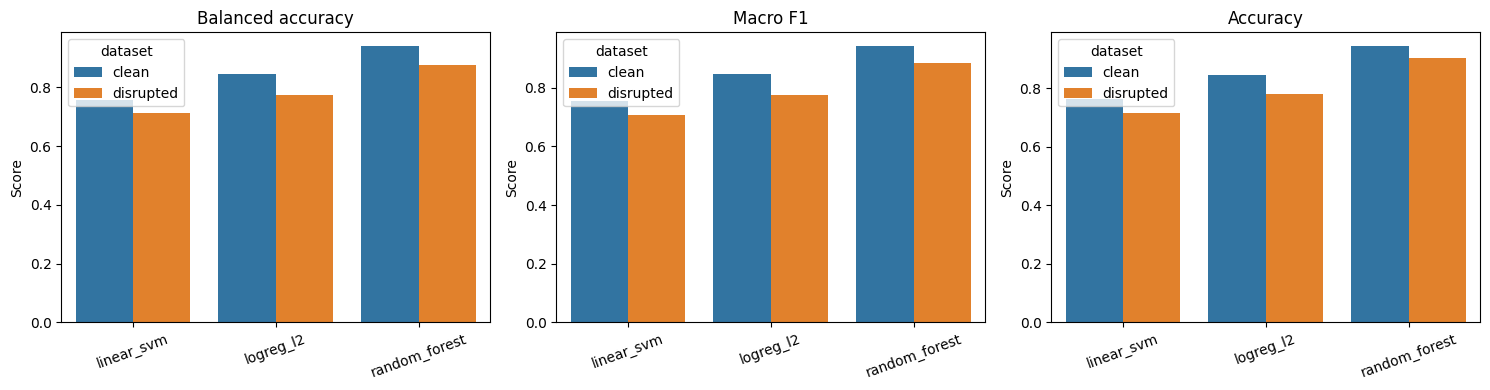

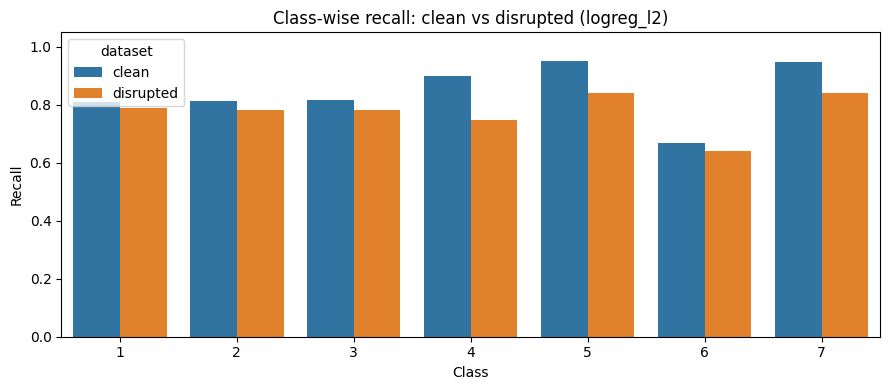

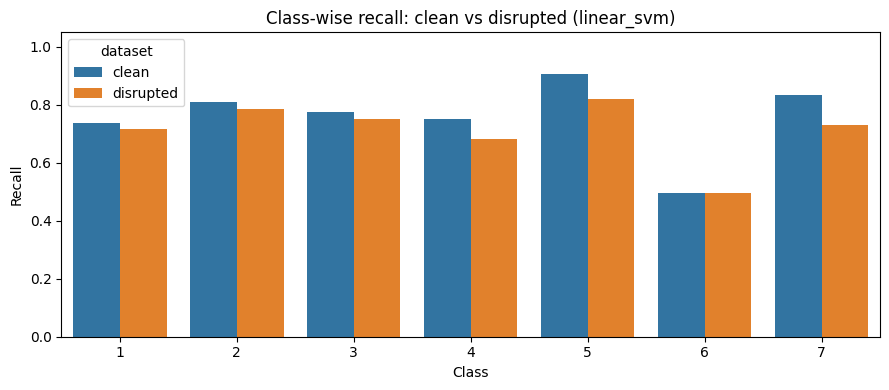

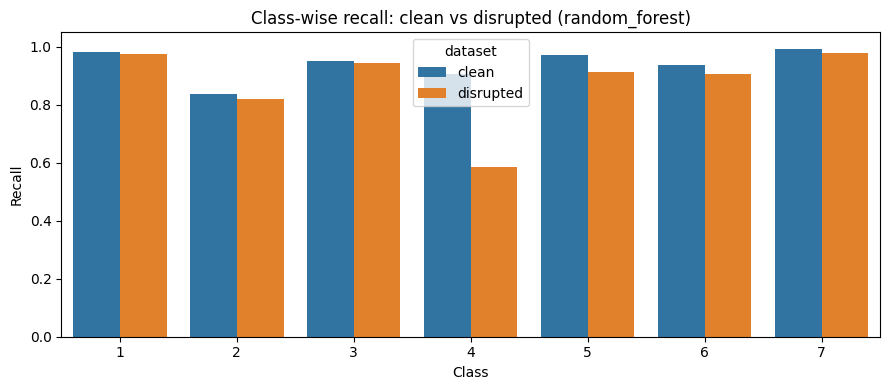

In [22]:
plot_summary = (
    results_1b
    .groupby(["dataset", "model"])[["balanced_accuracy", "macro_f1", "accuracy"]]
    .mean()
    .reset_index()
)

metrics = ["balanced_accuracy", "macro_f1", "accuracy"]
metric_names = {
    "balanced_accuracy": "Balanced accuracy",
    "macro_f1": "Macro F1",
    "accuracy": "Accuracy"
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=plot_summary,
        x="model",
        y=metric,
        hue="dataset",
        ax=ax
    )
    ax.set_title(metric_names[metric])
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

recall_cols = [c for c in results_1b.columns if c.startswith("recall_class_")]

for model in results_1b["model"].unique():
    model_df = results_1b[results_1b["model"] == model].copy()

    recall_plot = model_df.groupby("dataset")[recall_cols].mean().reset_index()
    recall_long = recall_plot.melt(
        id_vars="dataset",
        var_name="class",
        value_name="recall"
    )
    recall_long["class"] = recall_long["class"].str.replace("recall_class_", "", regex=False)

    plt.figure(figsize=(9, 4))
    sns.barplot(
        data=recall_long,
        x="class",
        y="recall",
        hue="dataset"
    )
    plt.ylim(0, 1.05)
    plt.title(f"Class-wise recall: clean vs disrupted ({model})")
    plt.xlabel("Class")
    plt.ylabel("Recall")
    plt.tight_layout()
    plt.show()

#######
PART 1c
#######

In [ ]:
pipe = models["random_forest"][0] #logreg_l2 

outer_seeds = [3, 6, 9]
outer_folds = 5

n = len(X_TR)
classes = np.sort(y_TR.unique())

# different metrics
self_prob_sum = np.zeros(n)
disagree_sum = np.zeros(n)
count_sum = np.zeros(n)

for seed in outer_seeds:
    cv = StratifiedKFold(n_splits=outer_folds, shuffle=True, random_state=seed)

    for train_idx, test_idx in cv.split(X_TR, y_TR):
        X_train, X_test = X_TR.iloc[train_idx], X_TR.iloc[test_idx]
        y_train, y_test = y_TR.iloc[train_idx], y_TR.iloc[test_idx]

        model = clone(pipe)
        model.fit(X_train, y_train)

        proba = model.predict_proba(X_test)
        pred = model.predict(X_test)

        class_to_col = {c: i for i, c in enumerate(model.named_steps["clf"].classes_)}

        for local_i, global_i in enumerate(test_idx):
            true_label = y_TR.iloc[global_i]
            self_prob_sum[global_i] += proba[local_i, class_to_col[true_label]]
            disagree_sum[global_i] += (pred[local_i] != true_label)
            count_sum[global_i] += 1

suspect_df_original = pd.DataFrame({
    "index": np.arange(n),
    "true_label": y_TR.values,
    "avg_self_prob": self_prob_sum / count_sum,
    "disagreement_rate": disagree_sum / count_sum
})

suspect_df_original["suspicion"] = ((1 - suspect_df_original["avg_self_prob"]) + suspect_df_original["disagreement_rate"])/2

suspect_df_original = suspect_df_original.sort_values("suspicion", ascending=False)
print(suspect_df_original.head(20))

      index  true_label  avg_self_prob  disagreement_rate  suspicion
5349   5349           2       0.060000                1.0   0.970000
606     606           2       0.064444                1.0   0.967778
7696   7696           2       0.066667                1.0   0.966667
797     797           2       0.066667                1.0   0.966667
344     344           2       0.068889                1.0   0.965556
6105   6105           2       0.068889                1.0   0.965556
4840   4840           2       0.073333                1.0   0.963333
8015   8015           2       0.073333                1.0   0.963333
371     371           5       0.073333                1.0   0.963333
7622   7622           5       0.073333                1.0   0.963333
7022   7022           4       0.073333                1.0   0.963333
5895   5895           2       0.075556                1.0   0.962222
6287   6287           2       0.075556                1.0   0.962222
1838   1838           4       0.07

In [ ]:
rf_pipe = models["random_forest"][0]


rng = np.random.RandomState(42)

# 5% noise
y_noisy = pd.Series(y_TR).copy().reset_index(drop=True)
classes = np.sort(y_noisy.unique())

n_flip = int(0.05 * len(y_noisy))
flip_idx = rng.choice(len(y_noisy), size=n_flip, replace=False)

for i in flip_idx:
    current = y_noisy.iloc[i]
    other_classes = classes[classes != current]
    y_noisy.iloc[i] = rng.choice(other_classes)

flip_idx = np.array(flip_idx)  # keep as array for later checks

print("Injected mislabeled observations:", len(flip_idx))

# cross-validation out of fold suspicion scoring on noisy labels

outer_seeds = [3, 6, 9]
outer_folds = 5

n = len(X_TR)
self_prob_sum = np.zeros(n)
disagree_sum = np.zeros(n)
count_sum = np.zeros(n)

for seed in outer_seeds:
    cv = StratifiedKFold(n_splits=outer_folds, shuffle=True, random_state=seed)

    for train_idx, test_idx in cv.split(X_TR, y_noisy):
        X_train, X_test = X_TR.iloc[train_idx], X_TR.iloc[test_idx]
        y_train, y_test = y_noisy.iloc[train_idx], y_noisy.iloc[test_idx]

        model = clone(rf_pipe)
        model.fit(X_train, y_train)

        proba = model.predict_proba(X_test)
        pred = model.predict(X_test)

        class_to_col = {c: i for i, c in enumerate(model.named_steps["clf"].classes_)}

        for local_i, global_i in enumerate(test_idx):
            true_label = y_noisy.iloc[global_i]
            self_prob_sum[global_i] += proba[local_i, class_to_col[true_label]]
            disagree_sum[global_i] += (pred[local_i] != true_label)
            count_sum[global_i] += 1

suspect_df_mislabel = pd.DataFrame({
    "index": np.arange(n),
    "true_label": y_noisy.values,
    "avg_self_prob": self_prob_sum / count_sum,
    "disagreement_rate": disagree_sum / count_sum
})

suspect_df_mislabel["suspicion"] = ((1 - suspect_df_mislabel["avg_self_prob"]) + suspect_df_mislabel["disagreement_rate"])/2
suspect_df_mislabel = suspect_df_mislabel.sort_values("suspicion", ascending=False).reset_index(drop=True)

print(suspect_df_mislabel.head(20))

Injected mislabeled observations: 404
    index  true_label  avg_self_prob  disagreement_rate  suspicion
0      23           4       0.008889                1.0   0.995556
1    6245           4       0.008889                1.0   0.995556
2    5593           4       0.008889                1.0   0.995556
3    2515           3       0.011111                1.0   0.994444
4    1479           4       0.013333                1.0   0.993333
5    2957           1       0.013333                1.0   0.993333
6    7034           4       0.013333                1.0   0.993333
7    3852           4       0.013333                1.0   0.993333
8    2517           2       0.013333                1.0   0.993333
9    1483           7       0.015556                1.0   0.992222
10   1803           3       0.015556                1.0   0.992222
11   1615           3       0.015556                1.0   0.992222
12    736           4       0.015556                1.0   0.992222
13    957           3   

In [ ]:
# checks
top_k = len(flip_idx)
top_detected = suspect_df_mislabel.head(top_k)["index"].values

caught = np.intersect1d(flip_idx, top_detected)

print("Injected mislabeled:", len(flip_idx))
print("Recovered in top-k suspicious:", len(caught))
print("Recovery rate:", len(caught) / len(flip_idx))

rank_map = {idx: rank for rank, idx in enumerate(suspect_df_mislabel["index"].values, start=1)}
ranks = [rank_map[i] for i in flip_idx]

print("Median rank of injected mislabeled points:", np.median(ranks))
print("Best rank among injected mislabeled points:", np.min(ranks))

Injected mislabeled: 404
Recovered in top-k suspicious: 321
Recovery rate: 0.7945544554455446
Median rank of injected mislabeled points: 202.5
Best rank among injected mislabeled points: 1


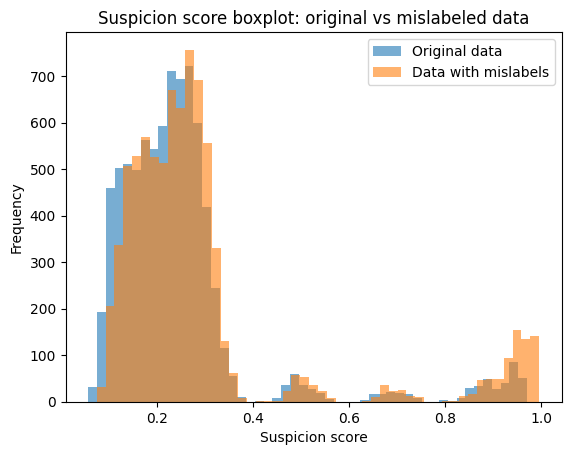

In [20]:
plt.figure()

plt.hist(
    suspect_df_original["suspicion"],
    bins=50,
    alpha=0.6,
    label="Original data"
)

plt.hist(
    suspect_df_mislabel["suspicion"],
    bins=50,
    alpha=0.6,
    label="Data with mislabels"
)

plt.xlabel("Suspicion score")
plt.ylabel("Frequency")
plt.legend()
plt.title("Suspicion score boxplot: original vs mislabeled data")

plt.show()

#######
PART 1d
#######

In [ ]:
models = {
    "logreg_l2": (
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("vt", VarianceThreshold()),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                l1_ratio=0,
                solver="saga",
                class_weight="balanced",
                max_iter=2000,
                random_state=42
            ))
        ]),
        {
            "clf__C": [0.1, 1.0]
        }
    ),
    "random_forest": (
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("vt", VarianceThreshold()),
            ("clf", RandomForestClassifier(
                class_weight="balanced_subsample",
                n_estimators=150,
                random_state=42,
                n_jobs=-1
            ))
        ]),
        {
            "clf__max_depth": [None, 20],
            "clf__min_samples_leaf": [1, 3]
        }
    )
}

In [ ]:
classes = np.sort(y_TR.unique())
class_to_idx = {c: i for i, c in enumerate(classes)}

sample_sizes = [1000, 3000, 8080]
seeds = [3, 6, 9]
outer_folds = 5

oof_rows = [] # out of fold summaries for training subsamples
test_rows = []    # X_TE predictions
test_prob_store = {}  # full probability matrices for X_TE
oof_prob_store = {}   # full out of fold probability matrices

def make_sample(X, y, sample_size, seed):
    if sample_size >= len(X):
        return X.copy().reset_index(drop=True), y.copy().reset_index(drop=True)

    X_sub, _, y_sub, _ = train_test_split(
        X, y,
        train_size=sample_size,
        stratify=y,
        random_state=seed
    )
    return X_sub.reset_index(drop=True), y_sub.reset_index(drop=True)

for sample_size in sample_sizes:
    print(f"\n================ SAMPLE SIZE: {sample_size} ================")

    for seed in seeds:
        print(f"\n--- seed {seed} ---")
        X_sub, y_sub = make_sample(X_TR, y_TR, sample_size, seed)

        for model_name, (pipe, param_grid) in models.items():
            print(f"Model: {model_name}")

            oof_proba_sum = np.zeros((len(X_sub), len(classes)))
            oof_count = np.zeros(len(X_sub), dtype=int)

            cv = StratifiedKFold(n_splits=outer_folds, shuffle=True, random_state=seed)

            for fold, (tr_idx, val_idx) in enumerate(cv.split(X_sub, y_sub), start=1):
                X_train, X_val = X_sub.iloc[tr_idx], X_sub.iloc[val_idx]
                y_train, y_val = y_sub.iloc[tr_idx], y_sub.iloc[val_idx]

                fitted = clone(pipe)
                fitted.fit(X_train, y_train)

                proba = fitted.predict_proba(X_val)
                pred = fitted.predict(X_val)

                fitted_classes = fitted.named_steps["clf"].classes_
                proba_full = np.zeros((len(val_idx), len(classes)))
                for j, c in enumerate(fitted_classes):
                    proba_full[:, class_to_idx[c]] = proba[:, j]

                oof_proba_sum[val_idx] += proba_full
                oof_count[val_idx] += 1

            oof_proba = oof_proba_sum / oof_count[:, None]
            oof_pred = classes[np.argmax(oof_proba, axis=1)]


            sorted_probs = np.sort(oof_proba, axis=1)
            max_prob = sorted_probs[:, -1]
            second_prob = sorted_probs[:, -2]
            margin = max_prob - second_prob

            oof_rows.append({
                "sample_size": sample_size,
                "seed": seed,
                "model": model_name,
                "oof_balanced_accuracy": balanced_accuracy_score(y_sub, oof_pred),
                "oof_macro_f1": f1_score(y_sub, oof_pred, average="macro"),
                "oof_accuracy": accuracy_score(y_sub, oof_pred),
                "oof_mean_max_prob": float(np.mean(max_prob)),
                "oof_mean_margin": float(np.mean(margin)),
                "oof_mean_max_prob_correct": float(np.mean(max_prob[oof_pred == y_sub])),
                "oof_mean_max_prob_wrong": float(np.mean(max_prob[oof_pred != y_sub])) if np.any(oof_pred != y_sub) else np.nan,
                "oof_error_rate": float(np.mean(oof_pred != y_sub))
            })

            oof_prob_store[(sample_size, seed, model_name)] = pd.DataFrame(
                oof_proba,
                columns=[f"prob_class_{c}" for c in classes]
            )

            # predict on X_TE
            final_model = clone(pipe)
            final_model.fit(X_sub, y_sub)

            te_proba = final_model.predict_proba(X_TE)
            te_pred = final_model.predict(X_TE)

            fitted_classes = final_model.named_steps["clf"].classes_
            te_proba_full = np.zeros((len(X_TE), len(classes)))
            for j, c in enumerate(fitted_classes):
                te_proba_full[:, class_to_idx[c]] = te_proba[:, j]

            te_sorted = np.sort(te_proba_full, axis=1)
            te_max_prob = te_sorted[:, -1]
            te_second_prob = te_sorted[:, -2]
            te_margin = te_max_prob - te_second_prob

            # overall summary for X_TE
            counts = pd.Series(te_pred).value_counts().sort_index()

            row = {
                "sample_size": sample_size,
                "seed": seed,
                "model": model_name,
                "te_mean_max_prob": float(np.mean(te_max_prob)),
                "te_mean_margin": float(np.mean(te_margin)),
            }

            # class level prediction counts on X_TE
            for c in classes:
                row[f"te_pred_count_class_{c}"] = int(np.sum(te_pred == c))

            test_rows.append(row)

            test_prob_store[(sample_size, seed, model_name)] = pd.DataFrame(
                te_proba_full,
                columns=[f"prob_class_{c}" for c in classes]
            )

            print(
                f"  OOF BA={oof_rows[-1]['oof_balanced_accuracy']:.3f} | "
                f"OOF F1={oof_rows[-1]['oof_macro_f1']:.3f} | "
                f"TE mean max prob={row['te_mean_margin']:.3f}"
            )


================ SAMPLE SIZE: 1000 ================

--- seed 3 ---
Model: logreg_l2
  OOF BA=0.662 | OOF F1=0.669 | TE mean max prob=0.655
Model: random_forest
  OOF BA=0.880 | OOF F1=0.892 | TE mean max prob=0.226

--- seed 6 ---
Model: logreg_l2
  OOF BA=0.692 | OOF F1=0.697 | TE mean max prob=0.639
Model: random_forest
  OOF BA=0.882 | OOF F1=0.894 | TE mean max prob=0.236

--- seed 9 ---
Model: logreg_l2
  OOF BA=0.644 | OOF F1=0.654 | TE mean max prob=0.664
Model: random_forest
  OOF BA=0.880 | OOF F1=0.892 | TE mean max prob=0.241

================ SAMPLE SIZE: 3000 ================

--- seed 3 ---
Model: logreg_l2
  OOF BA=0.757 | OOF F1=0.761 | TE mean max prob=0.794
Model: random_forest
  OOF BA=0.919 | OOF F1=0.926 | TE mean max prob=0.305

--- seed 6 ---
Model: logreg_l2
  OOF BA=0.743 | OOF F1=0.749 | TE mean max prob=0.799
Model: random_forest
  OOF BA=0.917 | OOF F1=0.924 | TE mean max prob=0.304

--- seed 9 ---
Model: logreg_l2
  OOF BA=0.762 | OOF F1=0.767 | TE mean m

In [5]:
oof_results_df = pd.DataFrame(oof_rows)
test_results_df = pd.DataFrame(test_rows)

print("\nOOF results:")
print(oof_results_df.head())

print("\nTest results:")
print(test_results_df.head())

# summaries by sample size and model
oof_summary = (
    oof_results_df
    .groupby(["sample_size", "model"])[
        ["oof_balanced_accuracy", "oof_macro_f1", "oof_accuracy",
         "oof_mean_max_prob", "oof_mean_margin",
         "oof_mean_max_prob_correct", "oof_mean_max_prob_wrong",
         "oof_error_rate"]
    ]
    .agg(["mean", "std"])
)

test_summary = (
    test_results_df
    .groupby(["sample_size", "model"])[
        ["te_mean_max_prob", "te_mean_margin"]
    ]
    .agg(["mean", "std"])
)

print("\nOOF summary:")
print(oof_summary)

print("\nTest summary:")
print(test_summary)

pred_count_cols = [c for c in test_results_df.columns if c.startswith("te_pred_count_class_")]
test_class_counts = (
    test_results_df
    .groupby(["sample_size", "model"])[pred_count_cols]
    .mean()
)

print("\nAverage predicted class counts on X_TE:")
print(test_class_counts)


OOF results:
   sample_size  seed          model  oof_balanced_accuracy  oof_macro_f1  \
0         1000     3      logreg_l2               0.661660      0.669496   
1         1000     3  random_forest               0.880429      0.892030   
2         1000     6      logreg_l2               0.692265      0.697399   
3         1000     6  random_forest               0.881876      0.893666   
4         1000     9      logreg_l2               0.644494      0.653721   

   oof_accuracy  oof_mean_max_prob  oof_mean_margin  \
0         0.686           0.772926         0.628261   
1         0.907           0.433293         0.246280   
2         0.710           0.784299         0.648560   
3         0.912           0.428760         0.235467   
4         0.661           0.773178         0.626173   

   oof_mean_max_prob_correct  oof_mean_max_prob_wrong  oof_error_rate  
0                   0.823638                 0.662136           0.314  
1                   0.445902                 0.310323 

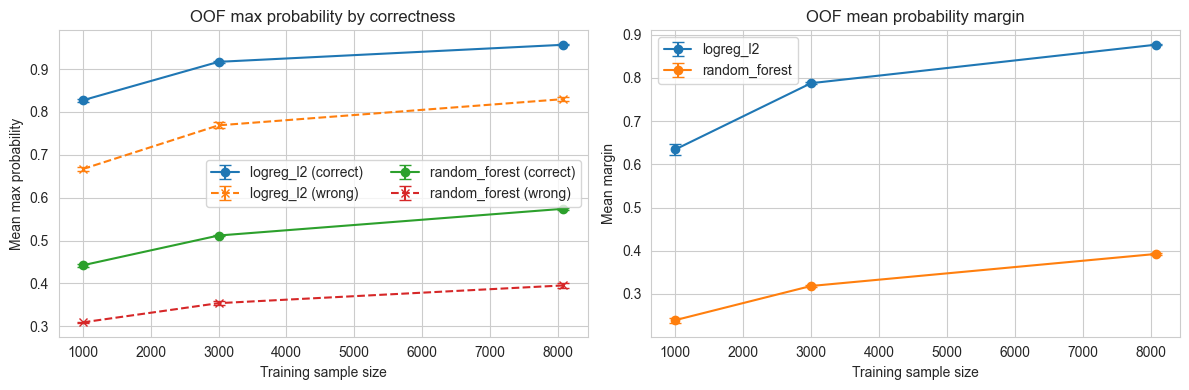

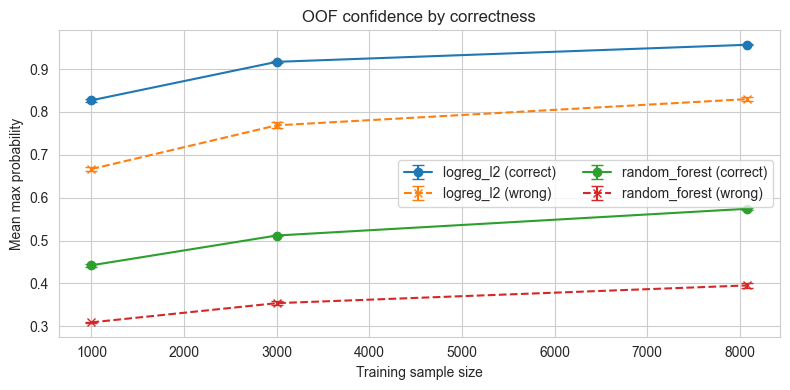

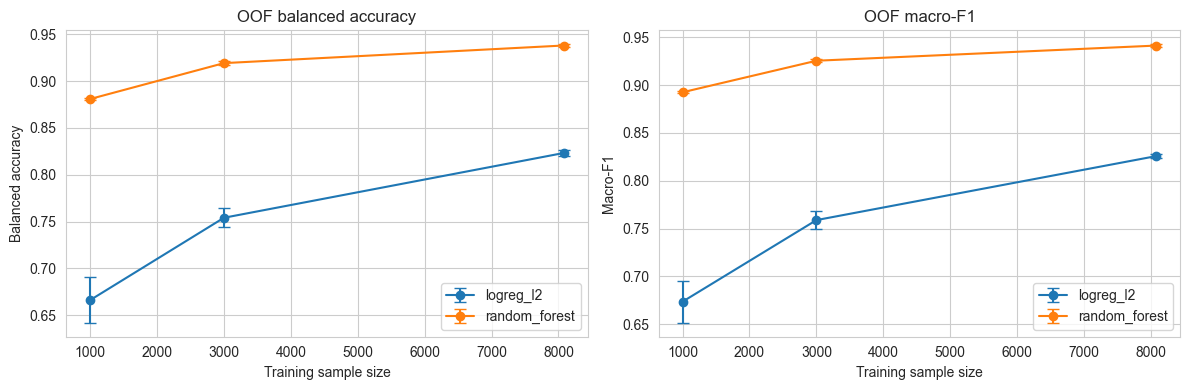

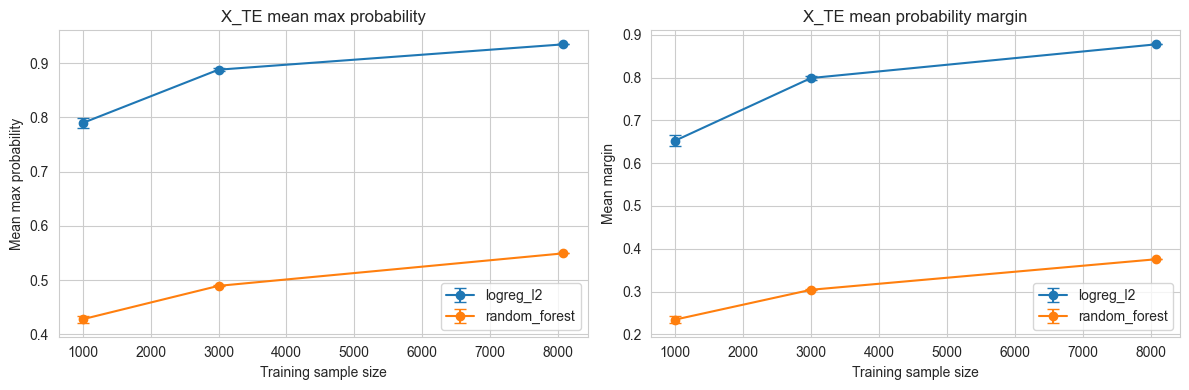

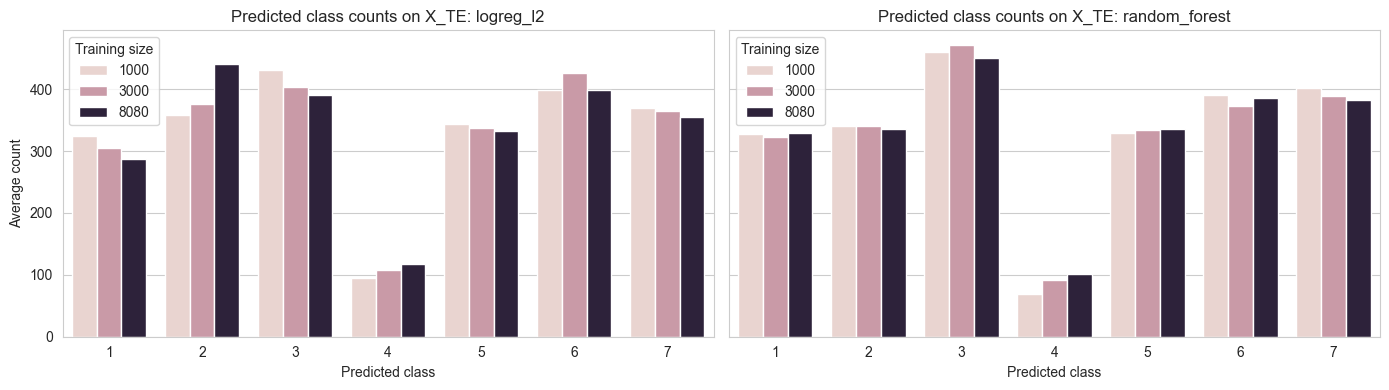

In [ ]:
# diverse plots for reporting results

sns.set_style("whitegrid")
oof_summary_simple = (
    oof_results_df
    .groupby(["sample_size", "model"], as_index=False)
    .agg({
        "oof_balanced_accuracy": ["mean", "std"],
        "oof_macro_f1": ["mean", "std"],
        "oof_accuracy": ["mean", "std"],
        "oof_mean_max_prob": ["mean", "std"],
        "oof_mean_margin": ["mean", "std"],
        "oof_mean_max_prob_correct": ["mean", "std"],
        "oof_mean_max_prob_wrong": ["mean", "std"],
        "oof_error_rate": ["mean", "std"],
    })
)
oof_summary_simple.columns = [
    "_".join([c for c in col if c]) if isinstance(col, tuple) else col
    for col in oof_summary_simple.columns
]

test_summary_simple = (
    test_results_df
    .groupby(["sample_size", "model"], as_index=False)
    .agg({
        "te_mean_max_prob": ["mean", "std"],
        "te_mean_margin": ["mean", "std"],
    })
)

test_summary_simple.columns = [
    "_".join([c for c in col if c]) if isinstance(col, tuple) else col
    for col in test_summary_simple.columns
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for model in oof_results_df["model"].unique():

    sub = (
        oof_summary_simple[oof_summary_simple["model"] == model]
        .sort_values("sample_size")
    )

    axes[0].errorbar(
        sub["sample_size"],
        sub["oof_mean_max_prob_correct_mean"],
        yerr=sub["oof_mean_max_prob_correct_std"],
        marker="o",
        capsize=4,
        label=f"{model} (correct)"
    )

    axes[0].errorbar(
        sub["sample_size"],
        sub["oof_mean_max_prob_wrong_mean"],
        yerr=sub["oof_mean_max_prob_wrong_std"],
        marker="x",
        linestyle="--",
        capsize=4,
        label=f"{model} (wrong)"
    )

    axes[1].errorbar(
        sub["sample_size"],
        sub["oof_mean_margin_mean"],
        yerr=sub["oof_mean_margin_std"],
        marker="o",
        capsize=4,
        label=model
    )

axes[0].set_title("OOF max probability by correctness")
axes[0].set_xlabel("Training sample size")
axes[0].set_ylabel("Mean max probability")

axes[1].set_title("OOF mean probability margin")
axes[1].set_xlabel("Training sample size")
axes[1].set_ylabel("Mean margin")

axes[0].legend(ncol=2)
axes[1].legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))

for model in oof_results_df["model"].unique():
    sub = oof_summary_simple[oof_summary_simple["model"] == model].sort_values("sample_size")
    ax.errorbar(
        sub["sample_size"],
        sub["oof_mean_max_prob_correct_mean"],
        yerr=sub["oof_mean_max_prob_correct_std"],
        marker="o",
        capsize=4,
        label=f"{model} (correct)"
    )
    ax.errorbar(
        sub["sample_size"],
        sub["oof_mean_max_prob_wrong_mean"],
        yerr=sub["oof_mean_max_prob_wrong_std"],
        marker="x",
        capsize=4,
        linestyle="--",
        label=f"{model} (wrong)"
    )

ax.set_title("OOF confidence by correctness")
ax.set_xlabel("Training sample size")
ax.set_ylabel("Mean max probability")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for model in oof_results_df["model"].unique():
    sub = oof_summary_simple[oof_summary_simple["model"] == model].sort_values("sample_size")
    axes[0].errorbar(
        sub["sample_size"],
        sub["oof_balanced_accuracy_mean"],
        yerr=sub["oof_balanced_accuracy_std"],
        marker="o",
        capsize=4,
        label=model
    )
    axes[1].errorbar(
        sub["sample_size"],
        sub["oof_macro_f1_mean"],
        yerr=sub["oof_macro_f1_std"],
        marker="o",
        capsize=4,
        label=model
    )

axes[0].set_title("OOF balanced accuracy")
axes[0].set_xlabel("Training sample size")
axes[0].set_ylabel("Balanced accuracy")

axes[1].set_title("OOF macro-F1")
axes[1].set_xlabel("Training sample size")
axes[1].set_ylabel("Macro-F1")

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for model in test_results_df["model"].unique():
    sub = test_summary_simple[test_summary_simple["model"] == model].sort_values("sample_size")
    axes[0].errorbar(
        sub["sample_size"],
        sub["te_mean_max_prob_mean"],
        yerr=sub["te_mean_max_prob_std"],
        marker="o",
        capsize=4,
        label=model
    )
    axes[1].errorbar(
        sub["sample_size"],
        sub["te_mean_margin_mean"],
        yerr=sub["te_mean_margin_std"],
        marker="o",
        capsize=4,
        label=model
    )

axes[0].set_title("X_TE mean max probability")
axes[0].set_xlabel("Training sample size")
axes[0].set_ylabel("Mean max probability")

axes[1].set_title("X_TE mean probability margin")
axes[1].set_xlabel("Training sample size")
axes[1].set_ylabel("Mean margin")

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

pred_count_cols = [c for c in test_results_df.columns if c.startswith("te_pred_count_class_")]

fig, axes = plt.subplots(1, len(test_results_df["model"].unique()), figsize=(14, 4), sharey=True)

if len(test_results_df["model"].unique()) == 1:
    axes = [axes]

for ax, model in zip(axes, sorted(test_results_df["model"].unique())):
    sub = (
        test_results_df[test_results_df["model"] == model]
        .groupby("sample_size")[pred_count_cols]
        .mean()
        .reset_index()
        .sort_values("sample_size")
    )

    long = sub.melt(id_vars="sample_size", var_name="class_col", value_name="count")
    long["class"] = long["class_col"].str.replace("te_pred_count_class_", "", regex=False)

    sns.barplot(data=long, x="class", y="count", hue="sample_size", ax=ax)
    ax.set_title(f"Predicted class counts on X_TE: {model}")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Average count")
    ax.legend(title="Training size")

plt.tight_layout()
plt.show()

In [17]:
X_domain = pd.concat([X_TR, X_TE], axis=0).reset_index(drop=True)

y_domain = np.array([0] * len(X_TR) + [1] * len(X_TE))  # 0 = train, 1 = test

for model_name, (domain_model, _) in models.items():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    domain_scores = cross_val_score(
        domain_model,
        X_domain,
        y_domain,
        cv=cv,
        scoring="balanced_accuracy",
        n_jobs=-1
    )

    print(f"\n{model_name}")
    print("Domain classifier balanced accuracy per fold:", domain_scores)
    print("Mean balanced accuracy:", domain_scores.mean())
    print("Std:", domain_scores.std())


logreg_l2
Domain classifier balanced accuracy per fold: [0.51502219 0.51651588 0.51176809 0.52745178 0.52622482]
Mean balanced accuracy: 0.5193965517241379
Std: 0.006279148943679414

random_forest
Domain classifier balanced accuracy per fold: [0.5 0.5 0.5 0.5 0.5]
Mean balanced accuracy: 0.5
Std: 0.0


#######
PART 2A
#######

In [ ]:
# building extreme dataset
X = X_TR.loc[:, ~X_TR.columns.astype(str).str.startswith("Unnamed")].reset_index(drop=True)
y = pd.Series(y_TR).reset_index(drop=True)

if not pd.api.types.is_numeric_dtype(y):
    le = LabelEncoder()
    y = pd.Series(le.fit_transform(y), name="target")

super_class = 7
n_super = 1000
n_minor = 50
rng = np.random.RandomState(42)

idx_parts = []

# supermajority class 7
idx_super = np.where(y.values == super_class)[0]
idx_super = rng.choice(idx_super, size=n_super, replace=False)
idx_parts.append(idx_super)

# minority classes
for cls in sorted(y.unique()):
    if cls == super_class:
        continue
    idx_cls = np.where(y.values == cls)[0]
    idx_cls = rng.choice(idx_cls, size=n_minor, replace=False)
    idx_parts.append(idx_cls)

idx_imb = np.concatenate(idx_parts)
rng.shuffle(idx_imb)

X_imb = X.iloc[idx_imb].reset_index(drop=True)
y_imb = y.iloc[idx_imb].reset_index(drop=True)

print("Altered class counts:")
print(y_imb.value_counts().sort_index())

classes = np.sort(y_imb.unique())
class_to_idx = {c: i for i, c in enumerate(classes)}

# models

def make_pipeline(model_name, strategy, seed):
    """
    strategy = 'plain', 'weighted', or 'oversample'
    """

    if model_name == "logreg_l2":
        clf_params = dict(
            l1_ratio=0,
            solver="saga",
            C=1.0,
            max_iter=2000,
            random_state=seed
        )
        if strategy == "weighted":
            clf_params["class_weight"] = "balanced"
        else:
            clf_params["class_weight"] = None

        steps = [
            ("imputer", SimpleImputer(strategy="median")),
            ("vt", VarianceThreshold()),
            ("scaler", StandardScaler()),
        ]

        if strategy == "oversample":
            steps.append(("ros", RandomOverSampler(random_state=seed)))

        steps.append(("clf", LogisticRegression(**clf_params)))
        return ImbPipeline(steps)

    if model_name == "linear_svm":
        clf_params = dict(
            C=1.0,
            max_iter=5000,
            random_state=seed,
            dual=False
        )
        if strategy == "weighted":
            clf_params["class_weight"] = "balanced"
        else:
            clf_params["class_weight"] = None

        steps = [
            ("imputer", SimpleImputer(strategy="median")),
            ("vt", VarianceThreshold()),
            ("scaler", StandardScaler()),
        ]

        if strategy == "oversample":
            steps.append(("ros", RandomOverSampler(random_state=seed)))

        steps.append(("clf", LinearSVC(**clf_params)))
        return ImbPipeline(steps)

    if model_name == "random_forest":
        clf_params = dict(
            n_estimators=150,
            random_state=seed,
            n_jobs=-1
        )
        if strategy == "weighted":
            clf_params["class_weight"] = "balanced_subsample"
        else:
            clf_params["class_weight"] = None

        steps = [
            ("imputer", SimpleImputer(strategy="median")),
            ("vt", VarianceThreshold()),
        ]

        if strategy == "oversample":
            steps.append(("ros", RandomOverSampler(random_state=seed)))

        steps.append(("clf", RandomForestClassifier(**clf_params)))
        return ImbPipeline(steps)

    raise ValueError("Unknown model name")

models = ["logreg_l2", "linear_svm", "random_forest"]
strategies = ["plain", "weighted", "oversample"]
seeds = [3, 6, 9]
outer_folds = 5

rows = []

for seed in seeds:
    cv = StratifiedKFold(n_splits=outer_folds, shuffle=True, random_state=seed)

    for model_name in models:
        for strategy in strategies:
            oof_pred = np.empty(len(y_imb), dtype=y_imb.dtype)

            print(f"\nStarting | seed={seed} | model={model_name} | strategy={strategy}")

            for tr_idx, val_idx in cv.split(X_imb, y_imb):
                X_train, X_val = X_imb.iloc[tr_idx], X_imb.iloc[val_idx]
                y_train = y_imb.iloc[tr_idx]

                pipe = make_pipeline(model_name, strategy, seed)
                pipe.fit(X_train, y_train)

                oof_pred[val_idx] = pipe.predict(X_val)

            row = {
                "seed": seed,
                "model": model_name,
                "strategy": strategy,
                "balanced_accuracy": balanced_accuracy_score(y_imb, oof_pred),
                "macro_f1": f1_score(y_imb, oof_pred, average="macro"),
                "accuracy": accuracy_score(y_imb, oof_pred),
            }

            per_class_recall = recall_score(
                y_imb,
                oof_pred,
                labels=classes,
                average=None,
                zero_division=0
            )

            for c, r in zip(classes, per_class_recall):
                row[f"recall_class_{c}"] = r

            rows.append(row)

results_imb = pd.DataFrame(rows)

print("\nRaw results:")
print(results_imb.head())

Altered class counts:
class
1      50
2      50
3      50
4      50
5      50
6      50
7    1000
Name: count, dtype: int64

Starting | seed=3 | model=logreg_l2 | strategy=plain

Starting | seed=3 | model=logreg_l2 | strategy=weighted

Starting | seed=3 | model=logreg_l2 | strategy=oversample

Starting | seed=3 | model=linear_svm | strategy=plain

Starting | seed=3 | model=linear_svm | strategy=weighted

Starting | seed=3 | model=linear_svm | strategy=oversample


c:\Users\erika\miniconda3\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Starting | seed=3 | model=random_forest | strategy=plain

Starting | seed=3 | model=random_forest | strategy=weighted

Starting | seed=3 | model=random_forest | strategy=oversample

Starting | seed=6 | model=logreg_l2 | strategy=plain

Starting | seed=6 | model=logreg_l2 | strategy=weighted

Starting | seed=6 | model=logreg_l2 | strategy=oversample

Starting | seed=6 | model=linear_svm | strategy=plain

Starting | seed=6 | model=linear_svm | strategy=weighted

Starting | seed=6 | model=linear_svm | strategy=oversample


c:\Users\erika\miniconda3\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Starting | seed=6 | model=random_forest | strategy=plain

Starting | seed=6 | model=random_forest | strategy=weighted

Starting | seed=6 | model=random_forest | strategy=oversample

Starting | seed=9 | model=logreg_l2 | strategy=plain

Starting | seed=9 | model=logreg_l2 | strategy=weighted

Starting | seed=9 | model=logreg_l2 | strategy=oversample

Starting | seed=9 | model=linear_svm | strategy=plain

Starting | seed=9 | model=linear_svm | strategy=weighted

Starting | seed=9 | model=linear_svm | strategy=oversample

Starting | seed=9 | model=random_forest | strategy=plain

Starting | seed=9 | model=random_forest | strategy=weighted

Starting | seed=9 | model=random_forest | strategy=oversample

Raw results:
   seed       model    strategy  balanced_accuracy  macro_f1  accuracy  \
0     3   logreg_l2       plain           0.531286  0.586692  0.873077   
1     3   logreg_l2    weighted           0.645000  0.681549  0.900769   
2     3   logreg_l2  oversample           0.627857  0.668


Summary:
                         balanced_accuracy            macro_f1            \
                                      mean       std      mean       std   
model         strategy                                                     
linear_svm    oversample          0.586333  0.006817  0.599564  0.009777   
              plain               0.581333  0.026930  0.584023  0.024978   
              weighted            0.583333  0.025567  0.586073  0.024379   
logreg_l2     oversample          0.631381  0.011829  0.671799  0.011880   
              plain               0.528238  0.024571  0.583493  0.026403   
              weighted            0.642857  0.017314  0.681396  0.017550   
random_forest oversample          0.232381  0.004364  0.276649  0.008343   
              plain               0.602857  0.021571  0.689521  0.023947   
              weighted            0.147619  0.001650  0.133507  0.003141   

                          accuracy            
                              

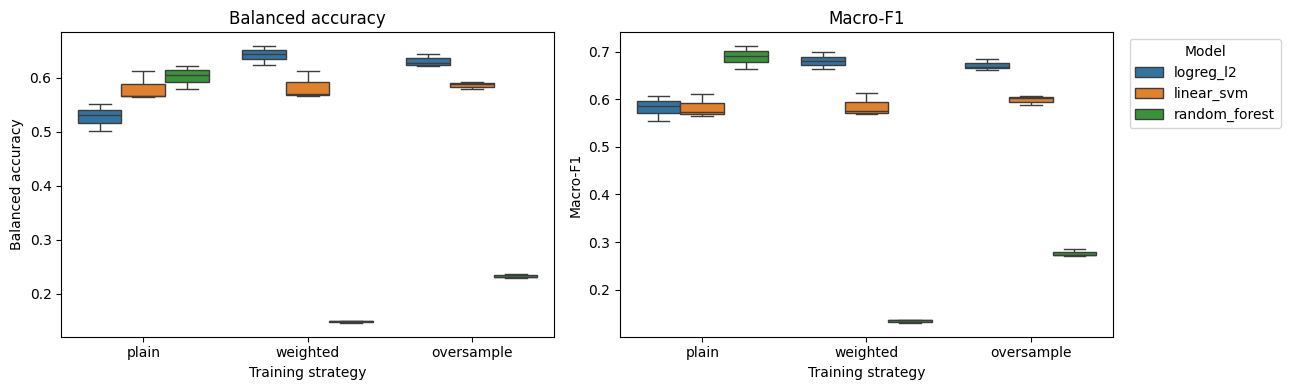


Mean minority-class recall (average over classes 1-6):
model          strategy  
linear_svm     oversample    0.524444
               plain         0.521111
               weighted      0.523333
logreg_l2      oversample    0.571111
               plain         0.450000
               weighted      0.584444
random_forest  oversample    0.104444
               plain         0.536667
               weighted      0.005556
dtype: float64


In [ ]:
summary_imb = (
    results_imb
    .groupby(["model", "strategy"])[["balanced_accuracy", "macro_f1", "accuracy"]]
    .agg(["mean", "std"])
)

print("\nSummary:")
print(summary_imb)

recall_cols = [c for c in results_imb.columns if c.startswith("recall_class_")]
recall_summary = (
    results_imb
    .groupby(["model", "strategy"])[recall_cols]
    .mean()
)

print("\nClass-wise recall summary:")
print(recall_summary)

plot_df = results_imb.copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

sns.boxplot(
    data=plot_df,
    x="strategy",
    y="balanced_accuracy",
    hue="model",
    ax=axes[0]
)
axes[0].set_title("Balanced accuracy")
axes[0].set_xlabel("Training strategy")
axes[0].set_ylabel("Balanced accuracy")

sns.boxplot(
    data=plot_df,
    x="strategy",
    y="macro_f1",
    hue="model",
    ax=axes[1]
)
axes[1].set_title("Macro-F1")
axes[1].set_xlabel("Training strategy")
axes[1].set_ylabel("Macro-F1")

axes[1].legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[0].legend_.remove()

plt.tight_layout()
plt.show()

minority_recall_cols = [c for c in recall_cols if c != "recall_class_7"]
minority_recall = results_imb.groupby(["model", "strategy"])[minority_recall_cols].mean().mean(axis=1)

print("\nMean minority-class recall (average over classes 1-6):")
print(minority_recall)

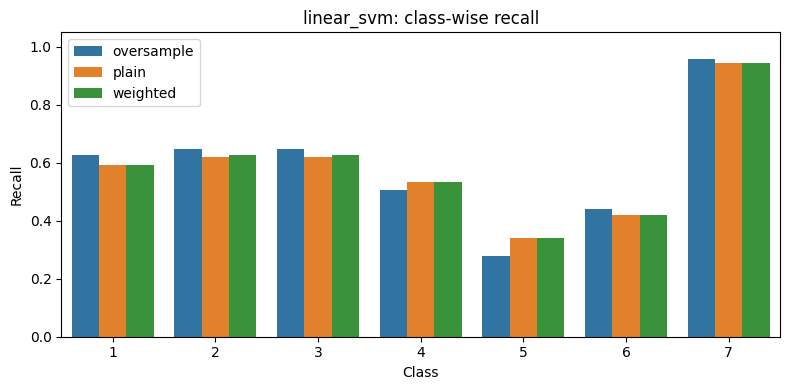

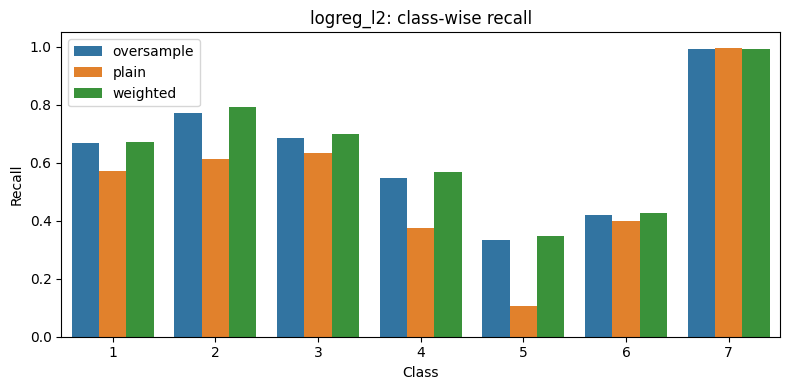

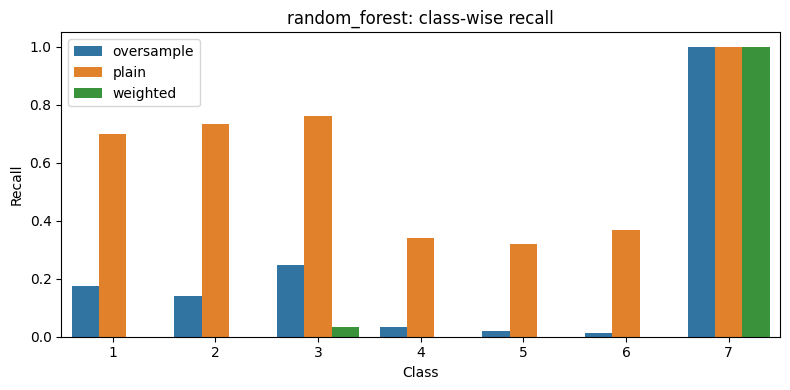

In [8]:
recall_summary_reset = recall_summary.reset_index()

recall_cols = [c for c in recall_summary_reset.columns
               if c.startswith("recall_class_")]

for model in recall_summary_reset["model"].unique():

    model_df = recall_summary_reset[
        recall_summary_reset["model"] == model
    ]

    plot_df = model_df.melt(
        id_vars=["strategy"],
        value_vars=recall_cols,
        var_name="class",
        value_name="recall"
    )

    plot_df["class"] = (
        plot_df["class"]
        .str.replace("recall_class_", "", regex=False)
    )

    plt.figure(figsize=(8, 4))

    sns.barplot(
        data=plot_df,
        x="class",
        y="recall",
        hue="strategy"
    )

    plt.ylim(0, 1.05)
    plt.title(f"{model}: class-wise recall")
    plt.ylabel("Recall")
    plt.xlabel("Class")
    plt.tight_layout()
    plt.legend()

    plt.show()

#######
PART 2b
#######

In [ ]:
X = X_TR.loc[:, ~X_TR.columns.astype(str).str.startswith("Unnamed")].reset_index(drop=True)
y = pd.Series(y_TR).reset_index(drop=True)

super_class = 7
n_super = 1000
n_minor = 50
rng = np.random.RandomState(42)

idx_parts = []

idx_super = np.where(y.values == super_class)[0]
idx_super = rng.choice(idx_super, size=n_super, replace=False)
idx_parts.append(idx_super)

for cls in sorted(y.unique()):
    if cls == super_class:
        continue
    idx_cls = np.where(y.values == cls)[0]
    idx_cls = rng.choice(idx_cls, size=n_minor, replace=False)
    idx_parts.append(idx_cls)

idx_imb = np.concatenate(idx_parts)
rng.shuffle(idx_imb)

X_imb = X.iloc[idx_imb].reset_index(drop=True)
y_imb = y.iloc[idx_imb].reset_index(drop=True)

print("Altered class counts:")
print(y_imb.value_counts().sort_index())

classes = np.sort(y_imb.unique())



def make_stage1_model(seed):
    # stage 1 with class 7 vs rest
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("vt", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            l1_ratio=0,
            solver="saga",
            class_weight="balanced",
            max_iter=10000,
            random_state=seed
        ))
    ])

def make_stage2_model(seed):
    # stage 2 with classes 1-6 only
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("vt", VarianceThreshold()),
        ("clf", RandomForestClassifier(
            n_estimators=150,
            random_state=seed,
            n_jobs=-1
        ))
    ])

def make_flat_baseline(seed):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("vt", VarianceThreshold()),
        ("clf", RandomForestClassifier(
            n_estimators=150,
            random_state=seed,
            n_jobs=-1
        ))
    ])

# hierarchical evaluation
outer_seeds = [3, 6, 9]
outer_folds = 5

rows = []

for seed in outer_seeds:
    cv = StratifiedKFold(n_splits=outer_folds, shuffle=True, random_state=seed)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_imb, y_imb), start=1):
        X_train, X_test = X_imb.iloc[train_idx], X_imb.iloc[test_idx]
        y_train, y_test = y_imb.iloc[train_idx], y_imb.iloc[test_idx]

        # stage 1 

        y_train_bin = (y_train == 7).astype(int)
        y_test_bin = (y_test == 7).astype(int)

        stage1 = make_stage1_model(seed)
        stage1.fit(X_train, y_train_bin)
        pred_stage1 = stage1.predict(X_test)

        stage1_bal_acc = balanced_accuracy_score(y_test_bin, pred_stage1)
        stage1_macro_f1 = f1_score(y_test_bin, pred_stage1)
        stage1_recall_7 = recall_score(y_test_bin, pred_stage1, zero_division=0)

        # stage 2
        minority_train_mask = y_train != 7
        minority_test_mask = y_test != 7

        stage2 = make_stage2_model(seed)
        stage2.fit(X_train.loc[minority_train_mask], y_train.loc[minority_train_mask])

        final_pred = np.full(len(X_test), 7, dtype=int)

        pred_minority_idx = np.where(pred_stage1 == 0)[0]
        if len(pred_minority_idx) > 0:
            final_pred[pred_minority_idx] = stage2.predict(X_test.iloc[pred_minority_idx])

        if minority_test_mask.any():
            stage2_true_minor_pred = stage2.predict(X_test.loc[minority_test_mask])
            stage2_bal_acc = balanced_accuracy_score(
                y_test.loc[minority_test_mask],
                stage2_true_minor_pred
            )
            stage2_macro_f1 = f1_score(
                y_test.loc[minority_test_mask],
                stage2_true_minor_pred,
                average="macro"
            )
        else:
            stage2_bal_acc = np.nan
            stage2_macro_f1 = np.nan

        row = {
            "seed": seed,
            "fold": fold,
            "stage1_balanced_accuracy": stage1_bal_acc,
            "stage1_macro_f1": stage1_macro_f1,
            "stage1_recall_class_7": stage1_recall_7,
            "stage2_balanced_accuracy_minority_only": stage2_bal_acc,
            "stage2_macro_f1_minority_only": stage2_macro_f1,
            "hier_balanced_accuracy": balanced_accuracy_score(y_test, final_pred),
            "hier_macro_f1": f1_score(y_test, final_pred, average="macro"),
            "hier_accuracy": accuracy_score(y_test, final_pred),
        }

        per_class_recall = recall_score(
            y_test,
            final_pred,
            labels=classes,
            average=None,
            zero_division=0
        )
        for c, r in zip(classes, per_class_recall):
            row[f"hier_recall_class_{c}"] = r

        rows.append(row)

hier_results_df = pd.DataFrame(rows)

print("\nHierarchical results head:")
print(hier_results_df.head())

baseline_rows = []

for seed in outer_seeds:
    cv = StratifiedKFold(n_splits=outer_folds, shuffle=True, random_state=seed)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_imb, y_imb), start=1):
        X_train, X_test = X_imb.iloc[train_idx], X_imb.iloc[test_idx]
        y_train, y_test = y_imb.iloc[train_idx], y_imb.iloc[test_idx]

        flat_rf = make_flat_baseline(seed)
        flat_rf.fit(X_train, y_train)
        pred_flat = flat_rf.predict(X_test)

        row = {
            "seed": seed,
            "fold": fold,
            "flat_balanced_accuracy": balanced_accuracy_score(y_test, pred_flat),
            "flat_macro_f1": f1_score(y_test, pred_flat, average="macro"),
            "flat_accuracy": accuracy_score(y_test, pred_flat),
        }

        per_class_recall = recall_score(
            y_test,
            pred_flat,
            labels=classes,
            average=None,
            zero_division=0
        )
        for c, r in zip(classes, per_class_recall):
            row[f"flat_recall_class_{c}"] = r

        baseline_rows.append(row)

flat_results_df = pd.DataFrame(baseline_rows)

print("\nFlat baseline head:")
print(flat_results_df.head())

Altered class counts:
class
1      50
2      50
3      50
4      50
5      50
6      50
7    1000
Name: count, dtype: int64

Hierarchical results head:
   seed  fold  stage1_balanced_accuracy  stage1_macro_f1  \
0     3     1                  0.845000         0.933002   
1     3     2                  0.888333         0.952854   
2     3     3                  0.837500         0.925000   
3     3     4                  0.855000         0.943489   
4     3     5                  0.821667         0.914573   

   stage1_recall_class_7  stage2_balanced_accuracy_minority_only  \
0                  0.940                                0.866667   
1                  0.960                                0.950000   
2                  0.925                                0.916667   
3                  0.960                                0.883333   
4                  0.910                                0.916667   

   stage2_macro_f1_minority_only  hier_balanced_accuracy  hier_macro_f1  \
0  

In [ ]:
hier_summary = hier_results_df[
    [
        "stage1_balanced_accuracy",
        "stage1_macro_f1",
        "stage1_recall_class_7",
        "stage2_balanced_accuracy_minority_only",
        "stage2_macro_f1_minority_only",
        "hier_balanced_accuracy",
        "hier_macro_f1",
        "hier_accuracy",
    ]
].agg(["mean", "std"])

flat_summary = flat_results_df[
    [
        "flat_balanced_accuracy",
        "flat_macro_f1",
        "flat_accuracy",
    ]
].agg(["mean", "std"])

print("\n============================================================")
print("HIERARCHICAL MODEL SUMMARY")
print("============================================================")
print(hier_summary)

print("\n============================================================")
print("FLAT RANDOM FOREST SUMMARY")
print("============================================================")
print(flat_summary)

hier_recall_cols = [
    c for c in hier_results_df.columns
    if c.startswith("hier_recall_class_")
]

flat_recall_cols = [
    c for c in flat_results_df.columns
    if c.startswith("flat_recall_class_")
]

hier_recall_summary = (
    hier_results_df[hier_recall_cols]
    .agg(["mean", "std"])
    .T
)

flat_recall_summary = (
    flat_results_df[flat_recall_cols]
    .agg(["mean", "std"])
    .T
)

print("\n============================================================")
print("HIERARCHICAL CLASS-WISE RECALL")
print("============================================================")
print(hier_recall_summary)

print("\n============================================================")
print("FLAT RANDOM FOREST CLASS-WISE RECALL")
print("============================================================")
print(flat_recall_summary)

comparison = pd.DataFrame({
    "Hierarchical Mean": [
        hier_results_df["hier_balanced_accuracy"].mean(),
        hier_results_df["hier_macro_f1"].mean(),
        hier_results_df["hier_accuracy"].mean()
    ],
    "Flat RF Mean": [
        flat_results_df["flat_balanced_accuracy"].mean(),
        flat_results_df["flat_macro_f1"].mean(),
        flat_results_df["flat_accuracy"].mean()
    ]
},
index=[
    "Balanced Accuracy",
    "Macro F1",
    "Accuracy"
])

print("\n============================================================")
print("OVERALL COMPARISON")
print("============================================================")
print(comparison.round(4))


HIERARCHICAL MODEL SUMMARY
      stage1_balanced_accuracy  stage1_macro_f1  stage1_recall_class_7  \
mean                  0.848444         0.931811               0.934667   
std                   0.020495         0.010895               0.018848   

      stage2_balanced_accuracy_minority_only  stage2_macro_f1_minority_only  \
mean                                0.881111                       0.878535   
std                                 0.040760                       0.041447   

      hier_balanced_accuracy  hier_macro_f1  hier_accuracy  
mean                0.686857       0.685650       0.867949  
std                 0.052656       0.052456       0.019647  

FLAT RANDOM FOREST SUMMARY
      flat_balanced_accuracy  flat_macro_f1  flat_accuracy
mean                0.602857       0.680152       0.893077
std                 0.049546       0.051979       0.013339

HIERARCHICAL CLASS-WISE RECALL
                         mean       std
hier_recall_class_1  0.886667  0.106010
hier_recall

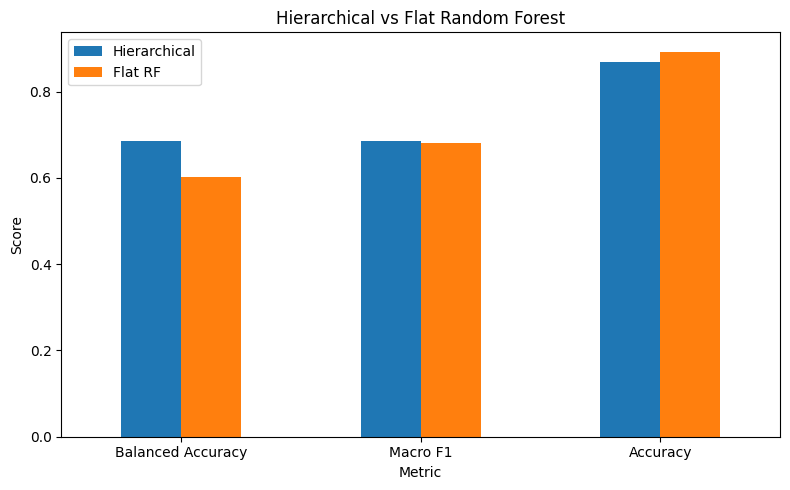

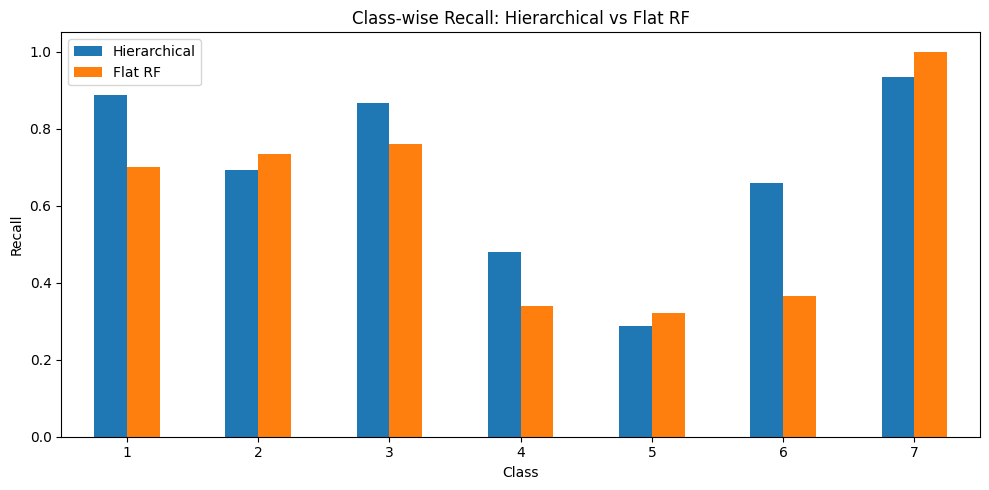

In [18]:
perf = pd.DataFrame({
    "Metric": ["Balanced Accuracy", "Macro F1", "Accuracy"],
    "Hierarchical": [0.686857, 0.685650, 0.867949],
    "Flat RF": [0.602857, 0.680152, 0.893077]
})

perf = perf.set_index("Metric")

ax = perf.plot(kind="bar", figsize=(8,5))
ax.set_ylabel("Score")
ax.set_title("Hierarchical vs Flat Random Forest")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

recall_df = pd.DataFrame({
    "Class": [1,2,3,4,5,6,7],
    "Hierarchical": [
        0.886667,
        0.693333,
        0.866667,
        0.480000,
        0.286667,
        0.660000,
        0.934667
    ],
    "Flat RF": [
        0.700000,
        0.733333,
        0.760000,
        0.340000,
        0.320000,
        0.366667,
        1.000000
    ]
})

recall_df = recall_df.set_index("Class")

ax = recall_df.plot(kind="bar", figsize=(10,5))
ax.set_ylabel("Recall")
ax.set_title("Class-wise Recall: Hierarchical vs Flat RF")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
